# Task 1

## Task 1.1

### a. Librerías
Las dependencias están en `requirements.txt`. Para instalarlas (en un entorno virtual):

```bash
python -m venv .venv
.venv\Scripts\activate          # Windows  (Linux/Mac: source .venv/bin/activate)
pip install -r requirements.txt
```

In [1]:
import io
import os
import re
import time
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import requests
import shapely
from shapely.geometry import Point, box
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.features import rasterize
from rasterio.io import MemoryFile
import pyproj
from scipy.spatial import cKDTree
from matplotlib_scalebar.scalebar import ScaleBar

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 160)

# Verificación de versiones solicitada en el enunciado
print("geopandas :", gpd.__version__)
print("shapely   :", shapely.__version__)
print("pandas    :", pd.__version__)
print("numpy     :", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("requests  :", requests.__version__)
print("rasterio  :", rasterio.__version__)
print("pyproj    :", pyproj.__version__)

geopandas : 1.2.0
shapely   : 2.1.2
pandas    : 3.0.6
numpy     : 2.5.3
matplotlib: 3.11.2
requests  : 2.34.2
rasterio  : 1.5.2
pyproj    : 3.8.0


In [ ]:
ISO3 = "GTM"
COUNTRY = "Guatemala"
CRS_GEO = "EPSG:4326"     # WGS84 geográfico (grados)
CRS_PROJ = "EPSG:32615"   # WGS84 / UTM zona 15N (metros) -> justificación en Task 1.2a
WP_YEAR = 2026            # año más reciente de WorldPop que no es posterior a la fecha de análisis (ver 1.1d)
RADII_KM = [5, 10, 20]    # radios de buffer de Task 1.3
SPEED_KMH = 40            # velocidad promedio por carretera (Task 2.1b)

DATA = Path("data")
DATA.mkdir(exist_ok=True)
HEADERS = {"User-Agent": "CC2017-lab5-modsim/1.0 (uso academico)"}

# Paleta (categórica en orden fijo; diverging azul<->rojo con gris neutro)
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NEUTRAL = "#f0efec"


def download(url, dest, params=None, timeout=300):
    """Descarga `url` a `dest` una sola vez (caché local). Garantiza reproducibilidad sin pasos manuales."""
    dest = Path(dest)
    if dest.exists() and dest.stat().st_size > 0:
        print(f"[caché]    {dest.name}")
        return dest
    print(f"[descarga] {url}")
    r = requests.get(url, params=params, headers=HEADERS, timeout=timeout)
    r.raise_for_status()
    dest.write_bytes(r.content)
    return dest


def pretty(name):
    """GADM 4.1 guarda los nombres sin espacios ('SanMiguelPanán'); se reinsertan para los mapas y tablas."""
    s = re.sub(r"(?<=[a-záéíóúñü])(?=[A-ZÁÉÍÓÚÑ])", " ", str(name))
    s = re.sub(r"([a-záéíóúñ])(de|del)(las|los|la)?(?= [A-ZÁÉÍÓÚÑ])",
               lambda m: f"{m[1]} {m[2]}" + (f" {m[3]}" if m[3] else ""), s)
    return s


def add_north_and_scale(ax, loc="lower left"):
    """Escala gráfica (las coordenadas están en metros) y flecha de norte."""
    ax.add_artist(ScaleBar(1, units="m", location=loc, box_alpha=0.8, length_fraction=0.25))
    ax.annotate("N", xy=(0.95, 0.95), xytext=(0.95, 0.84), xycoords="axes fraction",
                ha="center", va="center", fontsize=14, fontweight="bold",
                arrowprops=dict(facecolor="black", width=4, headwidth=12))

### b. Polígonos administrativos (GADM 4.1)

In [3]:
GADM_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_{iso}_{lvl}.json.zip"


def load_gadm(level):
    zpath = download(GADM_URL.format(iso=ISO3, lvl=level), DATA / f"gadm41_{ISO3}_{level}.json.zip")
    with zipfile.ZipFile(zpath) as zf:
        name = zf.namelist()[0]
        zf.extract(name, DATA)
    return gpd.read_file(DATA / name)


gadm1 = load_gadm(1)
gadm2_raw = load_gadm(2)
gadm1["NAME_1"] = gadm1["NAME_1"].map(pretty)
gadm2_raw["NAME_1"] = gadm2_raw["NAME_1"].map(pretty)
gadm2_raw["NAME_2"] = gadm2_raw["NAME_2"].map(pretty)

# Verificación del CRS: debe ser WGS84 (EPSG:4326)
for lbl, g in [("Nivel 1", gadm1), ("Nivel 2", gadm2_raw)]:
    print(f"{lbl}: {len(g):>3} polígonos | CRS = {g.crs} | ¿WGS84? {g.crs.to_epsg() == 4326}")
    assert g.crs.to_epsg() == 4326

print("\nTipos en nivel 2:", gadm2_raw["TYPE_2"].value_counts().to_dict())

[caché]    gadm41_GTM_1.json.zip
[caché]    gadm41_GTM_2.json.zip
Nivel 1:  22 polígonos | CRS = EPSG:4326 | ¿WGS84? True
Nivel 2: 354 polígonos | CRS = EPSG:4326 | ¿WGS84? True

Tipos en nivel 2: {'Municipio': 352, 'Waterbody': 2}


GADM incluye 2 polígonos de tipo `Waterbody` en el nivel 2 (Lago de Izabal y Lago de Atitlán). No son unidades
administrativas habitadas, así que se separan: los municipios de análisis son los 352 de tipo `Municipio`
(el municipio de Guatemala aparece dividido en sus zonas — `ZONA1`, `ZONA2`, … — en GADM; se conservan así).

In [4]:
water_gadm = gadm2_raw[gadm2_raw["TYPE_2"] == "Waterbody"].copy()
gadm2 = gadm2_raw[gadm2_raw["TYPE_2"] != "Waterbody"].reset_index(drop=True)
gadm2["mun"] = gadm2["NAME_2"] + " (" + gadm2["NAME_1"] + ")"   # etiqueta única
print("Municipios de análisis:", len(gadm2))
gadm1[["GID_1", "NAME_1", "TYPE_1", "geometry"]].head()

Municipios de análisis: 352


,GID_1,NAME_1,TYPE_1,geometry
0,GTM.1_1,Alta Verapaz,Departamento,"MULTIPOLYGON (((-89.6042 15.5026, -89.6148 15...."
1,GTM.2_1,Baja Verapaz,Departamento,"MULTIPOLYGON (((-90.4329 14.9088, -90.436 14.8..."
2,GTM.3_1,Chimaltenango,Departamento,"MULTIPOLYGON (((-90.8891 14.456, -90.8912 14.4..."
3,GTM.4_1,Chiquimula,Departamento,"MULTIPOLYGON (((-89.353 14.4195, -89.361 14.41..."
4,GTM.5_1,El Progreso,Departamento,"MULTIPOLYGON (((-90.2106 14.6863, -90.2384 14...."


### c. Instalaciones de salud (Global Healthsites Mapping Project)

In [5]:
HS_URL = "https://healthsites.io/api/v3/facilities/"
OVERPASS_URL = "https://overpass-api.de/api/interpreter"
MAIN_TYPES = ["hospital", "clinic", "doctors", "pharmacy", "dentist"]
TYPE_ES = {"hospital": "hospital", "clinic": "clínica", "doctors": "consultorio médico",
           "pharmacy": "farmacia", "dentist": "dentista", "other": "otro"}


def get_api_key():
    key = os.environ.get("HEALTHSITES_API_KEY")
    if not key and Path("healthsites_api_key.txt").exists():
        key = Path("healthsites_api_key.txt").read_text().strip()
    return key or None


def classify(amenity, healthcare):
    """Tipo de instalación según las etiquetas OSM que usa healthsites (amenity / healthcare)."""
    for v in (amenity, healthcare):
        v = v.lower() if isinstance(v, str) else ""
        if v == "doctor":
            v = "doctors"
        if v in MAIN_TYPES:
            return v
    return "other"


def fetch_healthsites(api_key, max_pages=500):
    rows, page = [], 1
    while page <= max_pages:
        r = requests.get(HS_URL, headers=HEADERS, timeout=120,
                         params={"api-key": api_key, "page": page, "country": COUNTRY,
                                 "output": "geojson", "flat-properties": "true"})
        if r.status_code in (400, 404):      # fin de la paginación
            break
        r.raise_for_status()
        data = r.json()
        feats = data.get("features", []) if isinstance(data, dict) else data
        if not feats:
            break
        for f in feats:
            props = dict(f.get("properties") or {})
            props.update(props.pop("attributes", None) or {})
            geom = f.get("geometry") or f.get("centroid")
            if not geom:
                continue
            lon, lat = geom["coordinates"][:2]
            rows.append({"osm_type": props.get("osm_type"), "osm_id": props.get("osm_id"),
                         "name": props.get("name"), "amenity": props.get("amenity"),
                         "healthcare": props.get("healthcare"), "lon": lon, "lat": lat})
        page += 1
        time.sleep(0.3)
    return pd.DataFrame(rows)


def fetch_overpass():
    """Respaldo: mismas etiquetas que healthsites.io (amenity=hospital|clinic|doctors|pharmacy|dentist, healthcare=*)."""
    q = f"""[out:json][timeout:170];
    area["ISO3166-1"="GT"][admin_level=2]->.a;
    (nwr["amenity"~"^(hospital|clinic|doctors|pharmacy|dentist)$"](area.a);
     nwr["healthcare"](area.a););
    out center tags;"""
    r = requests.post(OVERPASS_URL, data={"data": q}, headers=HEADERS, timeout=200)
    r.raise_for_status()
    rows = []
    for e in r.json()["elements"]:
        c = e if e["type"] == "node" else e.get("center")
        if not c:
            continue
        t = e.get("tags", {})
        rows.append({"osm_type": e["type"], "osm_id": e["id"], "name": t.get("name"),
                     "amenity": t.get("amenity"), "healthcare": t.get("healthcare"),
                     "lon": c["lon"], "lat": c["lat"]})
    return pd.DataFrame(rows)


fac_cache = DATA / "health_facilities_raw.csv"
if fac_cache.exists():
    fac_df = pd.read_csv(fac_cache)
    print(f"[caché]    {fac_cache.name}  (fuente: {fac_df['source'].iloc[0]})")
else:
    key = get_api_key()
    fac_df = pd.DataFrame()
    if key:
        print("Descargando desde healthsites.io API v3 ...")
        fac_df = fetch_healthsites(key).assign(source="healthsites.io API v3")
    if fac_df.empty:
        print("Sin llave de healthsites.io (o respuesta vacía) -> respaldo OpenStreetMap / Overpass API")
        fac_df = fetch_overpass().assign(source="OpenStreetMap (Overpass API)")
    fac_df.to_csv(fac_cache, index=False)

fac_df = fac_df.drop_duplicates(subset=["osm_type", "osm_id"])
fac_all = gpd.GeoDataFrame(fac_df, geometry=gpd.points_from_xy(fac_df.lon, fac_df.lat), crs=CRS_GEO)
fac_all["tipo"] = [classify(a, h) for a, h in zip(fac_all.amenity, fac_all.healthcare)]
print("Registros descargados:", len(fac_all))

[caché]    health_facilities_raw.csv  (fuente: OpenStreetMap (Overpass API))
Registros descargados: 2058


**Filtro espacial:** se conservan solo las instalaciones que intersectan algún polígono del nivel 1 (`sjoin` con
predicado `intersects`); así se eliminan registros fuera del país o con coordenadas erróneas.

In [6]:
fac = gpd.sjoin(fac_all, gadm1[["NAME_1", "geometry"]], how="inner", predicate="intersects")
fac = fac.drop(columns="index_right").drop_duplicates(subset=["osm_type", "osm_id"]).reset_index(drop=True)
print(f"Instalaciones dentro de Guatemala: {len(fac)}  (descartadas: {len(fac_all) - len(fac)})")

tipos = (fac["tipo"].value_counts().rename("n").to_frame()
         .assign(tipo_es=lambda d: d.index.map(TYPE_ES), pct=lambda d: 100 * d.n / d.n.sum()))
print("\nDetalle de la categoría 'other' (etiqueta healthcare):",
      fac.loc[fac.tipo == "other", "healthcare"].value_counts().to_dict())
tipos

Instalaciones dentro de Guatemala: 2058  (descartadas: 0)

Detalle de la categoría 'other' (etiqueta healthcare): {'laboratory': 29, 'yes': 16, 'centre': 4, 'alternative': 3, 'physiotherapist': 3, 'psychotherapist': 2, 'rehabilitation': 2, 'optometrist': 2, 'hospice': 2, 'podiatrist': 1, 'blood_donation': 1, 'birthing_centre': 1}


,n,tipo_es,pct
tipo,,,
pharmacy,1048,farmacia,50.92
clinic,352,clínica,17.10
hospital,298,hospital,14.48
dentist,184,dentista,8.94
doctors,110,consultorio médico,5.34
other,66,otro,3.21


Se usan los cinco tipos asistenciales que reconoce healthsites
(hospital, clínica, consultorio, farmacia, dentista). La categoría `other` (laboratorios, ópticas, fisioterapia,
medicina alternativa…) no ofrece atención primaria y se excluye del modelo para no inflar la cobertura.

In [7]:
fac = fac[fac["tipo"].isin(MAIN_TYPES)].reset_index(drop=True)
print("Instalaciones en el modelo:", len(fac))

Instalaciones en el modelo: 1992


### d. Ráster de población (WorldPop)

In [8]:
cat = requests.get("https://hub.worldpop.org/rest/data/pop/G2_CN_POP_R25A_1km",
                   params={"iso3": ISO3}, headers=HEADERS, timeout=60).json()["data"]
wp_files = {int(d["popyear"]): d["files"][0] for d in cat}
print("Años disponibles:", sorted(wp_files))
assert WP_YEAR in wp_files
WP_URL = wp_files[WP_YEAR]
wp_path = download(WP_URL, DATA / Path(WP_URL).name)

with rasterio.open(wp_path) as src:
    pop_geo = src.read(1, masked=True)
    wp_meta = src.meta.copy()
    wp_crs, wp_transform, wp_res, wp_bounds = src.crs, src.transform, src.res, src.bounds

lat_c = (wp_bounds.top + wp_bounds.bottom) / 2
res_x_m = wp_res[0] * 111_320 * np.cos(np.radians(lat_c))   # 1° de longitud = 111.32 km · cos(φ)
res_y_m = wp_res[1] * 110_574                                # 1° de latitud ≈ 110.574 km

# máximo: el ráster guarda personas por píxel -> densidad = personas / área del píxel (km²)
r_max, c_max = np.unravel_index(np.ma.argmax(pop_geo), pop_geo.shape)
lat_max = wp_transform.f + (r_max + 0.5) * wp_transform.e
px_area_max = (wp_res[0] * 111_320 * np.cos(np.radians(lat_max))) * res_y_m / 1e6

print(f"\nArchivo                : {wp_path.name}")
print(f"Sistema de coordenadas : {wp_crs}")
print(f"Resolución             : {wp_res[0]:.7f}° × {wp_res[1]:.7f}°  ≈ {res_x_m:,.0f} m × {res_y_m:,.0f} m (a φ={lat_c:.1f}°)")
print(f"Filas × columnas       : {wp_meta['height']} × {wp_meta['width']}")
print(f"Valor NoData           : {wp_meta['nodata']}")
print(f"Población total        : {pop_geo.sum():,.0f} habitantes")
print(f"Máximo por píxel       : {pop_geo.max():,.0f} personas  -> densidad máx ≈ {pop_geo.max() / px_area_max:,.0f} hab/km²")

Años disponibles: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030]
[caché]    gtm_pop_2026_CN_1km_R2025A_UA_v1.tif

Archivo                : gtm_pop_2026_CN_1km_R2025A_UA_v1.tif
Sistema de coordenadas : EPSG:4326
Resolución             : 0.0083333° × 0.0083333°  ≈ 893 m × 921 m (a φ=15.8°)
Filas × columnas       : 489 × 480
Valor NoData           : -99999.0
Población total        : 18,828,240 habitantes
Máximo por píxel       : 14,653 personas  -> densidad máx ≈ 17,721 hab/km²


## Task 1.2

### a. Reproyección y justificación del CRS

**CRS elegido: EPSG:32615 — WGS 84 / UTM zona 15N.**

In [9]:
xs_geo = wp_bounds.left + (np.arange(pop_geo.shape[1]) + 0.5) * wp_res[0]
ys_geo = wp_bounds.top - (np.arange(pop_geo.shape[0]) + 0.5) * wp_res[1]
LON, LAT = np.meshgrid(xs_geo, ys_geo)
popmask = (~pop_geo.mask) & (pop_geo.filled(0) > 0)
lon_p, lat_p, w_p = LON[popmask], LAT[popmask], pop_geo.filled(0)[popmask]

rows = []
for epsg in (32615, 32616):
    k = pyproj.Proj(f"EPSG:{epsg}").get_factors(lon_p, lat_p).meridional_scale
    err = np.abs(k - 1) * 100
    rows.append({"CRS": f"EPSG:{epsg}", "error escala máx (%)": err.max(),
                 "error escala medio ponderado por población (%)": np.average(err, weights=w_p)})
pd.DataFrame(rows).set_index("CRS")

,error escala máx (%),error escala medio ponderado por población (%)
CRS,,
EPSG:32615,0.28,0.05
EPSG:32616,0.35,0.17


El cálculo confirma la elección: con **EPSG:32615** el error de escala máximo es ≈ 0.28 % (extremo oriental, Izabal)
y el error **ponderado por población** es ≈ 0.05 %, tres veces menor que con la zona 16N (≈ 0.17 %). Para un buffer
de 10 km eso es un error de ~5 m para el habitante típico, irrelevante frente a la resolución de 1 km del ráster.

In [10]:
gadm1_p = gadm1.to_crs(CRS_PROJ)
gadm2_p = gadm2.to_crs(CRS_PROJ)
water_p = water_gadm.to_crs(CRS_PROJ)
fac_p = fac.to_crs(CRS_PROJ)
country_p = shapely.union_all(gadm1_p.geometry.values)

# --- Reproyección del ráster a UTM 15N con remuestreo 'sum' (conserva el total de personas) ---
pop_src = pop_geo.filled(0).astype("float32")
dst_transform, W, H = calculate_default_transform(wp_crs, CRS_PROJ, wp_meta["width"], wp_meta["height"],
                                                  *wp_bounds, resolution=1000)
pop_utm = np.zeros((H, W), dtype="float32")
reproject(pop_src, pop_utm, src_transform=wp_transform, src_crs=wp_crs, src_nodata=None,
          dst_transform=dst_transform, dst_crs=CRS_PROJ, dst_nodata=None, resampling=Resampling.sum)
pop_utm[pop_utm < 0] = 0
utm_profile = dict(driver="GTiff", height=H, width=W, count=1, dtype="float32",
                   crs=CRS_PROJ, transform=dst_transform, nodata=0)

print(f"Ráster UTM: {H} × {W} píxeles de 1000 m")
print(f"Población original (WGS84) : {pop_src.sum():,.0f}")
print(f"Población reproyectada     : {pop_utm.sum():,.0f}   (diferencia {100 * (pop_utm.sum() / pop_src.sum() - 1):+.2f} %)")
for name, g in [("gadm1", gadm1_p), ("gadm2", gadm2_p), ("instalaciones", fac_p)]:
    print(f"{name:<14} -> {g.crs}")

Ráster UTM: 458 × 435 píxeles de 1000 m
Población original (WGS84) : 18,828,240
Población reproyectada     : 18,828,238   (diferencia -0.00 %)
gadm1          -> EPSG:32615
gadm2          -> EPSG:32615
instalaciones  -> EPSG:32615


**Estructuras auxiliares (se reutilizan en todo el notebook).** Se trabaja con los centros de los píxeles UTM:

* `zone2`/`zone1`: rasterización de municipios/departamentos sobre la grilla del ráster (cada píxel pertenece a
  la división que contiene su centro — misma regla que `rasterio.mask` con `all_touched=False`). Con esto,
  la población de una división es $P_k = \sum_{i \in k} P_i$ (estadística zonal).
* `d_pix`: distancia de cada píxel a la instalación más cercana, $d_i = \min_j \lVert x_i - s_j \rVert$, calculada con
  un árbol k-d. Como $x_i \in C_r \iff d_i \le r$, esto permite evaluar la cobertura para cualquier radio sin
  reconstruir los buffers.

In [11]:
zone2 = rasterize(((g, i) for i, g in enumerate(gadm2_p.geometry)), out_shape=(H, W),
                  transform=dst_transform, fill=-1, dtype="int32")
zone1 = rasterize(((g, i) for i, g in enumerate(gadm1_p.geometry)), out_shape=(H, W),
                  transform=dst_transform, fill=-1, dtype="int32")
# Municipios más pequeños que un píxel (p. ej. ZONA4, 0.9 km²) no contienen ningún centro de píxel:
# se les asigna el píxel que contiene su punto representativo para que no queden con población 0.
for i in sorted(set(range(len(gadm2_p))) - set(np.unique(zone2))):
    pt = gadm2_p.geometry.iloc[i].representative_point()
    r_, c_ = rasterio.transform.rowcol(dst_transform, pt.x, pt.y)
    print(f"Municipio sin centro de píxel -> píxel ({r_}, {c_}): {gadm2_p['mun'].iloc[i]}")
    zone2[r_, c_] = i
cols, rows_ = np.meshgrid(np.arange(W), np.arange(H))
X = dst_transform.c + (cols + 0.5) * dst_transform.a
Y = dst_transform.f + (rows_ + 0.5) * dst_transform.e

inside = zone2 >= 0                                    # píxeles dentro de algún municipio
px_x, px_y = X[inside], Y[inside]
px_pop, px_z2, px_z1 = pop_utm[inside].astype(float), zone2[inside], zone1[inside]
P_TOTAL = px_pop.sum()

fac_xy = np.column_stack([fac_p.geometry.x, fac_p.geometry.y])
fac_tree = cKDTree(fac_xy)
d_pix, nn_pix = fac_tree.query(np.column_stack([px_x, px_y]))   # metros

print(f"Población asignada a municipios: {P_TOTAL:,.0f} ({100 * P_TOTAL / pop_utm.sum():.2f} % del ráster;"
      " el resto cae en píxeles de borde/lagos)")

Municipio sin centro de píxel -> píxel (358, 186): ZONA4 (Guatemala)
Población asignada a municipios: 18,711,833 (99.38 % del ráster; el resto cae en píxeles de borde/lagos)


### b. Mapa base de tres capas

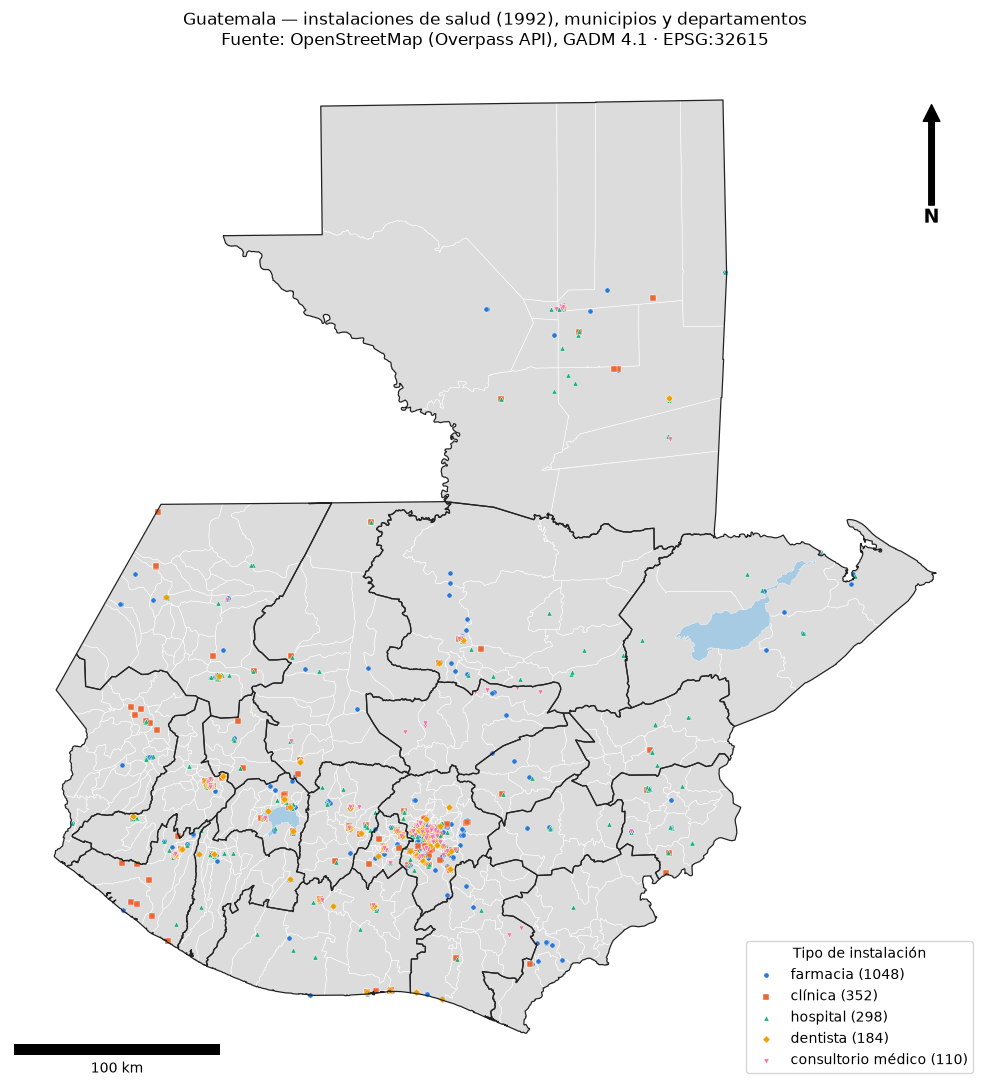

In [12]:
type_style = {  # color (orden categórico fijo) + forma de marcador (codificación secundaria)
    "pharmacy": (CAT[0], "o"), "clinic": (CAT[1], "s"), "hospital": (CAT[2], "^"),
    "dentist": (CAT[3], "D"), "doctors": (CAT[4], "v")}

fig, ax = plt.subplots(figsize=(11, 11))
gadm2_p.plot(ax=ax, color="#dcdcdc", edgecolor="white", linewidth=0.4)
water_p.plot(ax=ax, color="#a6cbe3", edgecolor="none")
for t, (col, mk) in type_style.items():
    sub = fac_p[fac_p.tipo == t]
    sub.plot(ax=ax, color=col, marker=mk, markersize=14, edgecolor="white", linewidth=0.3,
             label=f"{TYPE_ES[t]} ({len(sub)})", zorder=3)
gadm1_p.boundary.plot(ax=ax, color="#222222", linewidth=0.9, zorder=4)
ax.legend(title="Tipo de instalación", loc="lower right", frameon=True)
add_north_and_scale(ax)
ax.set_title(f"Guatemala — instalaciones de salud ({len(fac_p)}), municipios y departamentos\n"
             f"Fuente: {fac_df['source'].iloc[0]}, GADM 4.1 · {CRS_PROJ}", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### c. Estadísticas por departamento (nivel 1)

* **Población** $P_k$: suma de los píxeles WorldPop cuyo centro cae en el departamento (estadística zonal).
* **Instalaciones por 100,000 hab.:** $\rho_k = 10^5 \cdot n_k / P_k$.
* **Distancia promedio al vecino más cercano:** $\bar d^{NN}_k = \frac{1}{n_k}\sum_{j\in k} \min_{l \ne j} \lVert s_j - s_l\rVert$,
  calculada entre instalaciones del mismo departamento (árbol k-d, $k=2$ porque el primer vecino es el propio punto).

In [13]:
def mean_nn_km(pts):
    if len(pts) < 2:
        return np.nan
    d, _ = cKDTree(pts).query(pts, k=2)
    return d[:, 1].mean() / 1000


dept = gadm1_p[["NAME_1", "geometry"]].copy()
dept["instalaciones"] = dept["NAME_1"].map(fac_p["NAME_1"].value_counts()).fillna(0).astype(int)
dept["area_km2"] = dept.area / 1e6
dept["poblacion"] = np.bincount(px_z1[px_z1 >= 0], weights=px_pop[px_z1 >= 0], minlength=len(dept))
dept["inst_por_100k"] = 1e5 * dept["instalaciones"] / dept["poblacion"]
dept["dist_nn_prom_km"] = [mean_nn_km(fac_xy[fac_p["NAME_1"].values == n]) for n in dept["NAME_1"]]
dept_tbl = dept.drop(columns="geometry").sort_values("inst_por_100k").reset_index(drop=True)
dept_tbl.index += 1
dept_tbl

,NAME_1,instalaciones,area_km2,poblacion,inst_por_100k,dist_nn_prom_km
1,Totonicapán,7,"1,077.25","509,248.92",1.37,1.87
2,San Marcos,27,"3,541.66","1,277,661.63",2.11,1.30
3,El Progreso,5,"1,687.94","210,003.81",2.38,3.01
4,Jutiapa,15,"3,351.32","610,731.53",2.46,2.77
5,Santa Rosa,13,"3,023.90","482,857.37",2.69,3.08
6,Baja Verapaz,11,"2,821.31","344,362.91",3.19,7.16
7,Zacapa,10,"2,727.04","299,803.59",3.34,1.01
8,Jalapa,15,"1,972.96","436,235.54",3.44,2.01
9,Quiché,42,"7,231.63","1,203,121.11",3.49,1.48
10,Alta Verapaz,53,"10,061.75","1,456,242.33",3.64,2.49


In [14]:
low3 = dept_tbl.head(3)
print("Departamentos con MENOR densidad de cobertura (instalaciones por 100,000 hab.):")
for _, r in low3.iterrows():
    print(f"  - {r.NAME_1:<15} {r.inst_por_100k:5.2f} inst/100k hab | {r.instalaciones:>3} inst. para "
          f"{r.poblacion:,.0f} hab. | {r.area_km2:,.0f} km² | vecino más cercano prom. {r.dist_nn_prom_km:.1f} km")

Departamentos con MENOR densidad de cobertura (instalaciones por 100,000 hab.):
  - Totonicapán      1.37 inst/100k hab |   7 inst. para 509,249 hab. | 1,077 km² | vecino más cercano prom. 1.9 km
  - San Marcos       2.11 inst/100k hab |  27 inst. para 1,277,662 hab. | 3,542 km² | vecino más cercano prom. 1.3 km
  - El Progreso      2.38 inst/100k hab |   5 inst. para 210,004 hab. | 1,688 km² | vecino más cercano prom. 3.0 km


## Task 1.3

### a. Buffers de 5, 10 y 20 km y unión

Para cada radio $r$: $C_r = \bigcup_j B_r(s_j)$ con `shapely.union_all` (equivalente vectorizado de
`unary_union`). La unión elimina el doble conteo de población donde los buffers se traslapan.

In [15]:
coverage = {}
for r in RADII_KM:
    buffers = fac_p.geometry.buffer(r * 1000, quad_segs=32)        # metros, porque el CRS es UTM
    coverage[r] = shapely.union_all(buffers.values)
    inside_area = coverage[r].intersection(country_p).area / 1e6
    print(f"r = {r:>2} km: {len(buffers)} buffers -> 1 polígono ({coverage[r].geom_type}), "
          f"área cubierta dentro del país = {inside_area:,.0f} km² ({100 * inside_area / (country_p.area / 1e6):.1f} %)")

r =  5 km: 1992 buffers -> 1 polígono (MultiPolygon), área cubierta dentro del país = 14,455 km² (13.2 %)


r = 10 km: 1992 buffers -> 1 polígono (MultiPolygon), área cubierta dentro del país = 36,607 km² (33.5 %)


r = 20 km: 1992 buffers -> 1 polígono (MultiPolygon), área cubierta dentro del país = 70,054 km² (64.1 %)


### b. Población cubierta por radio

Se enmascara el ráster (UTM) con el polígono $C_r$ mediante `rasterio.mask.mask` y se suman los píxeles dentro de
la máscara: $P^{cub}_r = \sum_i P_i \, \mathbb{1}[x_i\in C_r]$; cobertura $=P^{cub}_r / P$.
Se verifica además que coincide con la versión por distancias $\sum_i P_i\,\mathbb{1}[d_i \le r]$, que se usa en
los cálculos repetitivos del Task 2.

In [16]:
memfile = MemoryFile()
pop_ds = memfile.open(**utm_profile)
pop_ds.write(pop_utm, 1)
country_mask, _ = rio_mask(pop_ds, [country_p], crop=False, filled=True, nodata=0)
P_COUNTRY = float(country_mask.sum())


def pop_in(geom):
    """Suma de población del ráster dentro de `geom` (y dentro del país)."""
    out, _ = rio_mask(pop_ds, [geom.intersection(country_p)], crop=False, filled=True, nodata=0)
    return float(out.sum())


cov_rows = []
for r in RADII_KM:
    pc = pop_in(coverage[r])
    cov_rows.append({"radio_km": r, "poblacion_cubierta": pc, "poblacion_total": P_COUNTRY,
                     "pct_cobertura": 100 * pc / P_COUNTRY,
                     "pct_verificación_kdtree": 100 * px_pop[d_pix <= r * 1000].sum() / P_TOTAL})
cov_tbl = pd.DataFrame(cov_rows)
cov_tbl

,radio_km,poblacion_cubierta,poblacion_total,pct_cobertura,pct_verificación_kdtree
0,5,"9,593,596.00","18,779,310.00",51.09,50.96
1,10,"13,361,816.00","18,779,310.00",71.15,71.08
2,20,"17,290,308.00","18,779,310.00",92.07,92.07


### c. Mapa de cobertura con radio de 10 km

Cada municipio se clasifica según la fracción de su **área** dentro de $C_{10}$:
completamente cubierto (≥ 99.5 %), parcialmente cubierto, o no cubierto (< 0.5 %). Escala divergente
rojo ↔ azul con gris neutro al centro: el rojo resalta las zonas sin cobertura.

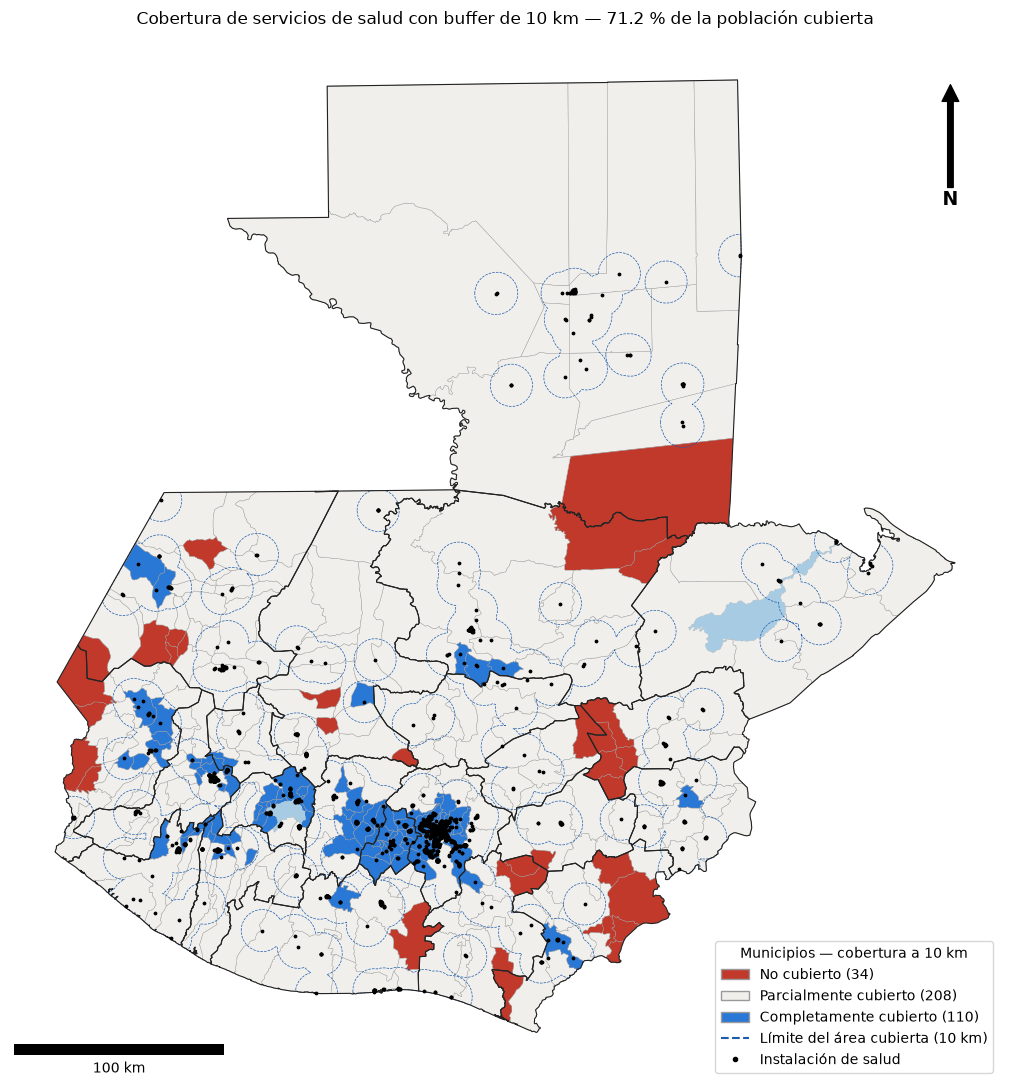

                        municipios
cobertura10                       
Parcialmente cubierto          208
Completamente cubierto         110
No cubierto                     34 

Municipios NO cubiertos (10 km) por departamento:
  Alta Verapaz   : Chahal, Fray Bartolomé de las Casas
  El Progreso    : San Cristóbal Acasaguastlán
  Escuintla      : Guanagazapa
  Huehuetenango  : Colotenango, San Gaspar Ixchil, San Ildefonso Ixtahuacán, San Rafael Petzal, San Sebastián Coatán, Tectitán
  Jalapa         : San Carlos Alzatate
  Jutiapa        : Asunción Mita, Atescatempa, El Adelanto, Jerez, Pasaco, Santa Catarina Mita, Yupiltepeque
  Petén          : San Luis
  Quiché         : Chinique, Pachalúm, San Bartolomé Jocotenango
  San Marcos     : Catarina, Malacatán, San Sibinal, Tacaná
  Santa Rosa     : Casillas, San Juan Tecuaco, San Rafaél Las Flores
  Zacapa         : Cabañas, Huité, San Diego, Teculután, Usumatlán


In [17]:
R = 10
cov10 = coverage[R]
gadm2_p["frac_area_cub10"] = gadm2_p.geometry.intersection(cov10).area / gadm2_p.area
gadm2_p["cobertura10"] = pd.cut(gadm2_p["frac_area_cub10"], [-0.01, 0.005, 0.995, 1.01],
                                labels=["No cubierto", "Parcialmente cubierto", "Completamente cubierto"])
DIV = {"No cubierto": "#c0392b", "Parcialmente cubierto": NEUTRAL, "Completamente cubierto": "#2a78d6"}

fig, ax = plt.subplots(figsize=(11, 11))
gadm2_p.plot(ax=ax, color=gadm2_p["cobertura10"].map(DIV).astype(str), edgecolor="#9a9a9a", linewidth=0.3)
water_p.plot(ax=ax, color="#a6cbe3")
gpd.GeoSeries([cov10.intersection(country_p)], crs=CRS_PROJ).boundary.plot(ax=ax, color="#1c5cab", linewidth=0.5,
                                                                         linestyle="--")
fac_p.plot(ax=ax, color="black", markersize=3, zorder=4)
gadm1_p.boundary.plot(ax=ax, color="#222222", linewidth=0.8)
counts = gadm2_p["cobertura10"].value_counts()
handles = [Patch(facecolor=c, edgecolor="#9a9a9a", label=f"{k} ({counts.get(k, 0)})") for k, c in DIV.items()]
handles += [Line2D([], [], color="#1c5cab", ls="--", label="Límite del área cubierta (10 km)"),
            Line2D([], [], marker="o", color="black", ls="", markersize=3, label="Instalación de salud")]
ax.legend(handles=handles, loc="lower right", title="Municipios — cobertura a 10 km")
add_north_and_scale(ax)
ax.set_title(f"Cobertura de servicios de salud con buffer de {R} km — "
             f"{cov_tbl.loc[cov_tbl.radio_km == R, 'pct_cobertura'].item():.1f} % de la población cubierta")
ax.set_axis_off()
plt.tight_layout()
plt.show()
print(counts.to_frame("municipios"), "\n\nMunicipios NO cubiertos (10 km) por departamento:")
for dpto, g in gadm2_p[gadm2_p.cobertura10 == "No cubierto"].groupby("NAME_1"):
    print(f"  {dpto:<15}: {', '.join(g.NAME_2)}")

**Lectura del mapa.** La mayoría de municipios (≈ 60 %) queda *parcialmente* cubierta: la cabecera municipal tiene
algún servicio, pero las aldeas alejadas no. Los 34 municipios **sin ninguna cobertura** forman tres grupos:
(i) el norte: San Luis (Petén), Chahal y Fray Bartolomé de las Casas (Alta Verapaz), en la Franja Transversal del
Norte; (ii) el altiplano occidental y central: Huehuetenango (6 municipios), San Marcos (4, incluido Malacatán) y
el sur de Quiché; y (iii) municipios rurales del oriente y sur-oriente (Jutiapa con 7, Zacapa con 5, Santa Rosa,
Jalapa, El Progreso). El resto de Petén aparece “parcialmente cubierto” solo porque sus municipios son enormes y
sus cabeceras tienen servicios; la mayor parte de su territorio queda fuera de los círculos. Los municipios completamente cubiertos están en el corredor Ciudad de Guatemala –
Antigua – Chimaltenango, en Quetzaltenango, Sololá (Lago de Atitlán) y cabeceras como Cobán y Huehuetenango.

# Task 2

## Task 2.1

Estadísticas por municipio (estadística zonal sobre los píxeles):
* Población no cubierta a 10 km: $U_k = \sum_{i\in k} P_i\,\mathbb{1}[d_i > 10\text{ km}]$.
* **Centroide poblacional** $\bar x_k = \sum_{i\in k} P_i x_i / \sum_{i\in k} P_i$ — representa dónde vive la gente
  del municipio mejor que el centroide geométrico; la "distancia a la instalación más cercana" se mide desde ahí.

In [18]:
n2 = len(gadm2_p)
valid = px_z2 >= 0
z, p, d = px_z2[valid], px_pop[valid], d_pix[valid]
bc = lambda w: np.bincount(z, weights=w, minlength=n2)

mun = gadm2_p[["GID_2", "NAME_1", "NAME_2", "mun", "geometry"]].copy()
mun["area_km2"] = mun.area / 1e6
mun["poblacion"] = bc(p)
mun["pob_no_cubierta10"] = bc(p * (d > 10_000))
mun["pob_cubierta10"] = mun["poblacion"] - mun["pob_no_cubierta10"]
mun["instalaciones"] = np.bincount(
    gpd.sjoin(fac_p[["geometry"]], mun[["geometry"]], predicate="within")["index_right"], minlength=n2)

# centroide poblacional y su instalación más cercana
with np.errstate(invalid="ignore", divide="ignore"):
    cx, cy = bc(p * px_x[valid]) / mun["poblacion"], bc(p * px_y[valid]) / mun["poblacion"]
geo_c = mun.geometry.representative_point()
cx, cy = np.where(mun["poblacion"] > 0, cx, geo_c.x), np.where(mun["poblacion"] > 0, cy, geo_c.y)
dc, jc = fac_tree.query(np.column_stack([cx, cy]))
mun["dist_inst_cercana_km"] = dc / 1000
mun["tipo_inst_cercana"] = fac_p["tipo"].values[jc]
mun["nombre_inst_cercana"] = fac_p["name"].fillna("(sin nombre)").values[jc]
# distancia media ponderada por población (se usa en Task 2.2)
with np.errstate(invalid="ignore", divide="ignore"):
    mun["dist_media_pob_km"] = bc(p * d) / mun["poblacion"] / 1000

### a. Cinco municipios con mayor población no cubierta (10 km)

In [19]:
top5 = mun.sort_values("pob_no_cubierta10", ascending=False).head(5).copy()
top5["tipo_inst_cercana"] = top5["tipo_inst_cercana"].map(TYPE_ES)
top5_tbl = top5[["NAME_2", "NAME_1", "poblacion", "pob_no_cubierta10", "dist_inst_cercana_km",
                 "tipo_inst_cercana", "nombre_inst_cercana"]].reset_index(drop=True)
top5_tbl.index += 1
top5_tbl

,NAME_2,NAME_1,poblacion,pob_no_cubierta10,dist_inst_cercana_km,tipo_inst_cercana,nombre_inst_cercana
1,Chisec,Alta Verapaz,"172,346.38","155,938.03",22.34,farmacia,(sin nombre)
2,San Pedro Carchá,Alta Verapaz,"281,990.44","154,563.51",15.64,farmacia,(sin nombre)
3,Joyabaj,Quiché,"136,465.08","130,707.50",19.68,farmacia,Farmacia
4,La Libertad,Petén,"137,333.68","130,179.25",24.08,farmacia,Gemelitas
5,Malacatán,San Marcos,"122,939.64","122,939.64",19.51,farmacia,(sin nombre)


### b. Radio mínimo para cubrir cada municipio y tiempo de viaje a 40 km/h

Una división queda cubierta con radio $r$ si todos sus puntos están a distancia $\le r$ de alguna instalación.
Por tanto el radio mínimo es $r^*_k = \max_{i \in k} d_i$:
* $r^*_{pob}$: máximo sobre los píxeles **habitados** (cubre al 100 % de la población).
* $r^*_{95}$: percentil 95 ponderado por población (cubre al 95 % — menos sensible a un caserío aislado).
* $r^*_{área}$: máximo sobre **todos** los píxeles del municipio (cobertura de todo el territorio).

Tiempo de viaje aproximado: $t = r^* / v$, con $v = 40$ km/h. Es una cota inferior: la distancia real por
carretera es mayor que la euclidiana (factor de rodeo típico 1.3–1.5 en terreno montañoso).

In [20]:
def weighted_quantile(values, weights, q):
    o = np.argsort(values)
    cw = np.cumsum(weights[o])
    return values[o][np.searchsorted(cw, q * cw[-1])]


rows = []
for k, r in top5.iterrows():
    sel = z == k
    dk, pk = d[sel], p[sel]
    r_pob = dk[pk > 0].max() / 1000
    r_95 = weighted_quantile(dk, pk, 0.95) / 1000
    r_area = dk.max() / 1000
    rows.append({"municipio": r.NAME_2, "departamento": r.NAME_1,
                 "r_min_95%pob_km": r_95, "r_min_100%pob_km": r_pob, "r_min_area_km": r_area,
                 "t_95%pob_min": 60 * r_95 / SPEED_KMH, "t_100%pob_min": 60 * r_pob / SPEED_KMH,
                 "t_area_min": 60 * r_area / SPEED_KMH})
rmin_tbl = pd.DataFrame(rows)
rmin_tbl.index += 1
rmin_tbl

,municipio,departamento,r_min_95%pob_km,r_min_100%pob_km,r_min_area_km,t_95%pob_min,t_100%pob_min,t_area_min
1,Chisec,Alta Verapaz,40.21,47.60,47.60,60.32,71.39,71.39
2,San Pedro Carchá,Alta Verapaz,19.29,27.91,27.91,28.94,41.87,41.87
3,Joyabaj,Quiché,20.08,20.91,20.91,30.13,31.37,31.37
4,La Libertad,Petén,69.46,116.37,131.69,104.18,174.55,197.54
5,Malacatán,San Marcos,24.32,25.70,25.70,36.48,38.54,38.54


### c. Curva de cobertura acumulada (1–50 km)

$\text{Cob}(r) = \sum_i P_i\,\mathbb{1}[d_i \le r] / P$, para $r = 1,\dots,50$ km. Es exactamente la población
dentro de $\bigcup_j B_r(s_j)$, pero evaluada con las distancias $d_i$ en lugar de reconstruir 50 uniones de polígonos.

**Punto de inflexión.** La curva es cóncava (crece más rápido a radios pequeños), por lo que el punto relevante
es el *codo* o punto de rendimientos decrecientes. Se identifica con el método **Kneedle**: tras normalizar
ambos ejes a [0, 1], el codo es el radio que maximiza la distancia vertical entre la curva y la recta que une sus
extremos, $r^{knee} = \arg\max_r\,[\tilde{C}(r) - \tilde{r}]$. Como criterio complementario se reporta el primer radio
en que la ganancia marginal $\Delta \text{Cob}(r) = \text{Cob}(r) - \text{Cob}(r-1)$ cae por debajo de 1 punto porcentual por km.

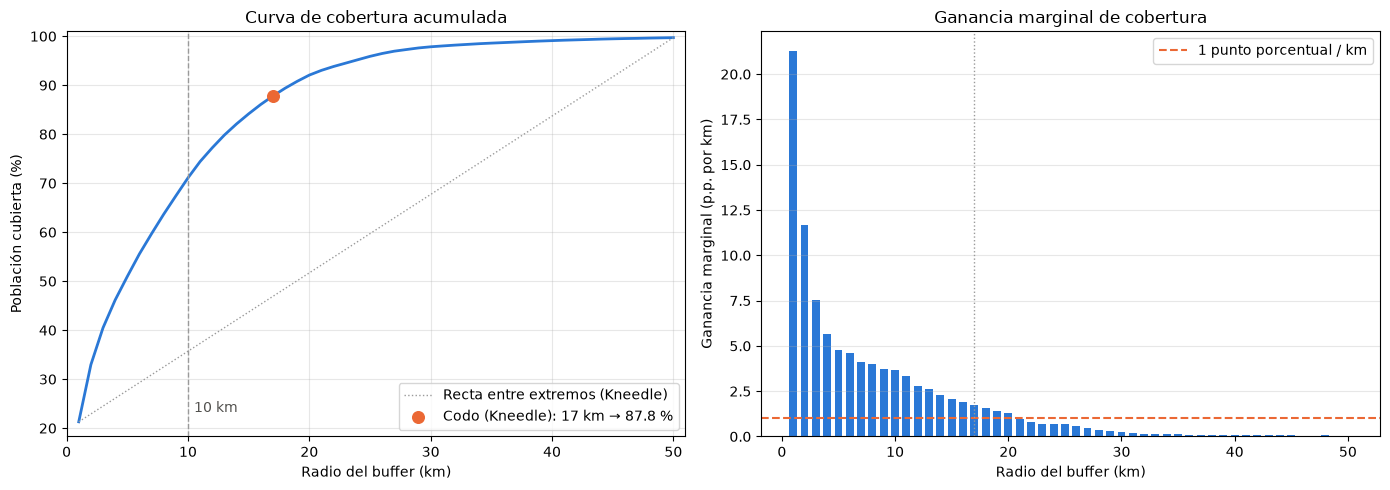

Codo (Kneedle): r = 17 km, cobertura = 87.8 %
Primer radio con ganancia marginal < 1 p.p./km: r = 21 km, cobertura = 93.0 %
Cobertura a 50 km: 99.71 %


radio_km,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
pct_cobertura,21.30,33.00,40.50,46.20,51.00,55.60,59.70,63.70,67.40,71.10,...,99.20,99.30,99.30,99.40,99.50,99.50,99.60,99.60,99.70,99.70
ganancia_pp,21.30,11.70,7.50,5.70,4.80,4.60,4.10,4.00,3.70,3.70,...,0.10,0.10,0.10,0.10,0.10,0.10,0.00,0.10,0.00,0.00


In [21]:
radii = np.arange(1, 51)
curve = np.array([100 * p[d <= r * 1000].sum() / P_TOTAL for r in radii])
marg = np.diff(np.concatenate([[100 * p[d == 0].sum() / P_TOTAL], curve]))

xn = (radii - radii.min()) / (radii.max() - radii.min())
yn = (curve - curve.min()) / (curve.max() - curve.min())
r_knee = radii[np.argmax(yn - xn)]
r_1pp = radii[np.argmax(marg < 1)]
c_knee = curve[radii == r_knee].item()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.plot(radii, curve, color=CAT[0], lw=2)
a1.plot([radii[0], radii[-1]], [curve[0], curve[-1]], color="#9a9a9a", lw=1, ls=":", label="Recta entre extremos (Kneedle)")
a1.scatter([r_knee], [c_knee], color=CAT[1], s=70, zorder=3, label=f"Codo (Kneedle): {r_knee} km → {c_knee:.1f} %")
a1.axvline(10, color="#9a9a9a", lw=1, ls="--")
a1.text(10.5, curve.min() + 2, "10 km", color="#52514e")
a1.set(xlabel="Radio del buffer (km)", ylabel="Población cubierta (%)", title="Curva de cobertura acumulada",
       xlim=(0, 51), ylim=(curve.min() - 3, 101))
a1.grid(alpha=0.3)
a1.legend(loc="lower right")
a2.bar(radii, marg, color=CAT[0], width=0.7)
a2.axhline(1, color=CAT[1], lw=1.5, ls="--", label="1 punto porcentual / km")
a2.axvline(r_knee, color="#9a9a9a", lw=1, ls=":")
a2.set(xlabel="Radio del buffer (km)", ylabel="Ganancia marginal (p.p. por km)",
       title="Ganancia marginal de cobertura")
a2.grid(alpha=0.3, axis="y")
a2.legend()
plt.tight_layout()
plt.show()

print(f"Codo (Kneedle): r = {r_knee} km, cobertura = {c_knee:.1f} %")
print(f"Primer radio con ganancia marginal < 1 p.p./km: r = {r_1pp} km, cobertura = {curve[radii == r_1pp].item():.1f} %")
print(f"Cobertura a 50 km: {curve[-1]:.2f} %")
pd.DataFrame({"radio_km": radii, "pct_cobertura": curve, "ganancia_pp": marg}).set_index("radio_km").T.round(1)

## Task 2.2

| Componente | Variable cruda por municipio $k$ | Dirección |
|---|---|---|
| $C_1$ distancia | $\bar d_k = \sum_{i\in k}P_i d_i / \sum_{i\in k}P_i$ — distancia media ponderada por población a la instalación más cercana (km) | más = más vulnerable |
| $C_2$ densidad sin cobertura | $U_k / A_k$ — habitantes **no cubiertos a 10 km** por km² | más = más vulnerable |
| $C_3$ instalaciones per cápita | $10^4 \cdot n_k / P_k$ — instalaciones por 10,000 hab. | menos = más vulnerable → se invierte: $1 - \tilde{x}$ |

Para $C_1$ se usa la distancia media de la población (y no la del centroide) porque mide la distancia que
efectivamente recorre un habitante típico del municipio.

### a. Normalización min-max
$\tilde x_k = \dfrac{x_k - \min_l x_l}{\max_l x_l - \min_l x_l} \in [0,1]$.

In [22]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())


mun["x1_dist_km"] = mun["dist_media_pob_km"]
mun["x2_dens_no_cub"] = mun["pob_no_cubierta10"] / mun["area_km2"]
mun["x3_inst_10k"] = np.where(mun["poblacion"] > 0, 1e4 * mun["instalaciones"] / mun["poblacion"], 0)

mun["C1"] = minmax(mun["x1_dist_km"])
mun["C2"] = minmax(mun["x2_dens_no_cub"])
mun["C3"] = 1 - minmax(mun["x3_inst_10k"])      # se invierte: pocas instalaciones per cápita = vulnerable
mun[["x1_dist_km", "x2_dens_no_cub", "x3_inst_10k", "C1", "C2", "C3"]].describe().T[["mean", "50%", "min", "max"]]

,mean,50%,min,max
x1_dist_km,8.05,6.06,0.04,47.25
x2_dens_no_cub,66.52,19.90,0.00,619.64
x3_inst_10k,0.95,0.00,0.00,16.72
C1,0.17,0.13,0.00,1.00
C2,0.11,0.03,0.00,1.00
C3,0.94,1.00,0.00,1.00


### b. Pesos del índice

$V_k = w_1 C_{1,k} + w_2 C_{2,k} + w_3 C_{3,k}$, con $w_1 + w_2 + w_3 = 1$.

In [23]:
WEIGHTS = {"C1": 0.40, "C2": 0.35, "C3": 0.25}
mun["V"] = sum(w * mun[c] for c, w in WEIGHTS.items())

LABELS = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
mun["V_cat"] = pd.qcut(mun["V"], 5, labels=LABELS)
top10 = mun.sort_values("V", ascending=False).head(10)
top10_tbl = top10[["NAME_2", "NAME_1", "poblacion", "x1_dist_km", "x2_dens_no_cub", "x3_inst_10k",
                   "C1", "C2", "C3", "V"]].reset_index(drop=True)
top10_tbl.index += 1
top10_tbl

,NAME_2,NAME_1,poblacion,x1_dist_km,x2_dens_no_cub,x3_inst_10k,C1,C2,C3,V
1,San Gaspar Ixchil,Huehuetenango,"22,325.67",21.95,597.03,0.00,0.46,0.96,1.00,0.77
2,Colotenango,Huehuetenango,"32,845.96",20.43,563.49,0.00,0.43,0.91,1.00,0.74
3,San Rafael Petzal,Huehuetenango,"22,908.67",16.05,619.64,0.00,0.34,1.00,1.00,0.74
4,Malacatán,San Marcos,"122,939.64",18.61,534.97,0.00,0.39,0.86,1.00,0.71
5,San Ildefonso Ixtahuacán,Huehuetenango,"117,437.71",22.66,453.00,0.00,0.48,0.73,1.00,0.70
6,San Andrés,Petén,"29,638.23",47.25,3.30,0.00,1.00,0.01,1.00,0.65
7,Catarina,San Marcos,"33,927.31",16.91,417.85,0.00,0.36,0.67,1.00,0.63
8,Huitán,Quezaltenango,"16,447.61",12.65,463.44,0.00,0.27,0.75,1.00,0.62
9,Chahal,Alta Verapaz,"27,295.34",36.07,94.87,0.00,0.76,0.15,1.00,0.61
10,Fray Bartolomé de las Casas,Alta Verapaz,"77,817.79",35.40,74.93,0.00,0.75,0.12,1.00,0.59


### c. Mapa coroplético por quintiles con los 10 municipios más vulnerables

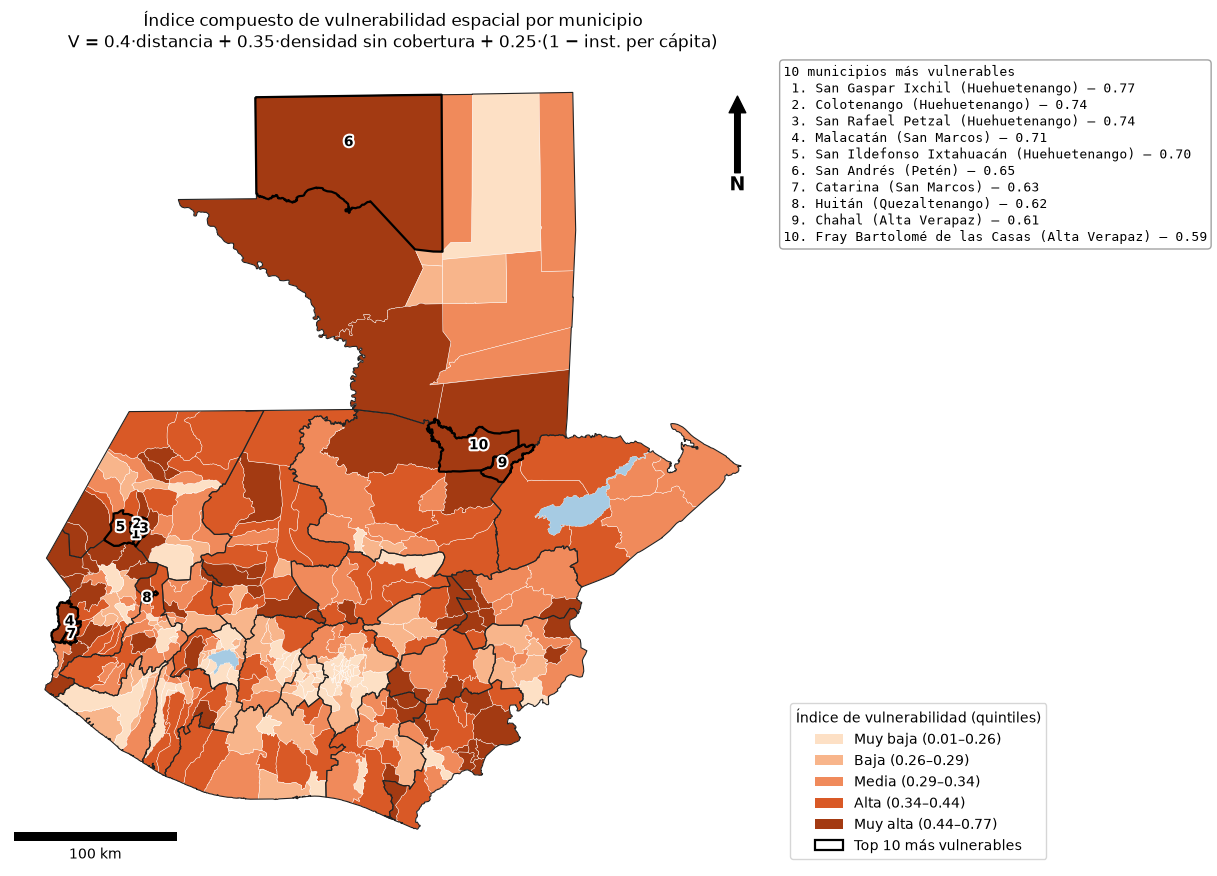

In [24]:
SEQ = ["#fde0c5", "#f8b58b", "#f08a5b", "#d95926", "#a33a12"]   # un solo tono (naranja), claro -> oscuro
fig, ax = plt.subplots(figsize=(12, 12))
mun.plot(ax=ax, color=mun["V_cat"].map(dict(zip(LABELS, SEQ))).astype(str), edgecolor="white", linewidth=0.3)
water_p.plot(ax=ax, color="#a6cbe3")
gadm1_p.boundary.plot(ax=ax, color="#222222", linewidth=0.8)
top10.boundary.plot(ax=ax, color="black", linewidth=1.6)
names = []
for rank, (_, r) in enumerate(top10.iterrows(), start=1):
    pt = r.geometry.representative_point()
    ax.annotate(str(rank), xy=(pt.x, pt.y), fontsize=10, fontweight="bold", ha="center", va="center",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")])
    names.append(f"{rank:>2}. {r.NAME_2} ({r.NAME_1}) — {r.V:.2f}")
# los nombres van en un recuadro: en el altiplano los municipios son tan pequeños que se traslaparían
ax.text(1.01, 0.99, "10 municipios más vulnerables\n" + "\n".join(names), transform=ax.transAxes,
        va="top", ha="left", fontsize=9, family="monospace",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#9a9a9a", alpha=0.92))
bins = mun.groupby("V_cat", observed=True)["V"].agg(["min", "max"])
handles = [Patch(facecolor=c, label=f"{l} ({bins.loc[l, 'min']:.2f}–{bins.loc[l, 'max']:.2f})")
           for l, c in zip(LABELS, SEQ)]
handles.append(Patch(facecolor="none", edgecolor="black", linewidth=1.6, label="Top 10 más vulnerables"))
ax.legend(handles=handles, title="Índice de vulnerabilidad (quintiles)", loc="lower left", bbox_to_anchor=(1.01, 0))
add_north_and_scale(ax, loc="lower left")
ax.set_title("Índice compuesto de vulnerabilidad espacial por municipio\n"
             f"V = {WEIGHTS['C1']}·distancia + {WEIGHTS['C2']}·densidad sin cobertura + {WEIGHTS['C3']}·(1 − inst. per cápita)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Task 2.3

**Formulación MCLP (Church & ReVelle, 1974)** adaptada a cobertura existente:

$$\max \sum_{i} a_i\, y_i \quad \text{s.a.}\quad y_i \le \sum_{j \in N_i} x_j,\qquad \sum_j x_j = p,\qquad x_j, y_i \in \{0,1\}$$

donde $i$ son los píxeles de demanda **sin cobertura actual** con peso $a_i = P_i$, $j$ los puntos candidatos,
$N_i = \{j : \lVert x_i - c_j \rVert \le S\}$ con $S = 10$ km, y $p = 5$ nuevas instalaciones.

### a. Grilla de candidatos (20 km)
Se eliminan los puntos fuera del país (intersección con el nivel 1) y los que caen en cuerpos de agua
(polígonos `Waterbody` de GADM + lagos de Natural Earth 1:10m, p. ej. Lago Petén Itzá).

In [25]:
SPACING, S = 20_000, 10_000
minx, miny, maxx, maxy = country_p.bounds
gx, gy = np.meshgrid(np.arange(minx + SPACING / 2, maxx, SPACING), np.arange(miny + SPACING / 2, maxy, SPACING))
grid = gpd.GeoDataFrame(geometry=gpd.points_from_xy(gx.ravel(), gy.ravel()), crs=CRS_PROJ)

ne_zip = download("https://naciscdn.org/naturalearth/10m/physical/ne_10m_lakes.zip", DATA / "ne_10m_lakes.zip")
lakes = gpd.read_file(ne_zip).to_crs(CRS_PROJ)
lakes = lakes[lakes.intersects(country_p)]
water_all = shapely.union_all(list(water_p.geometry) + list(lakes.geometry))

in_country = grid.intersects(country_p)
in_water = grid.intersects(water_all)
cand = grid[in_country & ~in_water].reset_index(drop=True)
print(f"Puntos de la grilla: {len(grid)} | fuera del país: {(~in_country).sum()} | "
      f"en cuerpos de agua: {(in_country & in_water).sum()} | candidatos: {len(cand)}")
print("Lagos de Natural Earth en el país:", ", ".join(lakes["name"].dropna().unique()))

[caché]    ne_10m_lakes.zip


Puntos de la grilla: 483 | fuera del país: 207 | en cuerpos de agua: 2 | candidatos: 274
Lagos de Natural Earth en el país: Lago de Izabal


### b. Población adicional por candidato
$g_j = \sum_{i \in M_j} P_i\,(1 - c_i)$, donde $M_j$ son los píxeles a ≤ 10 km del candidato $j$ y $c_i = \mathbb{1}[d_i \le 10\text{ km}]$
indica si el píxel ya está cubierto por la red actual.

In [26]:
pix_xy = np.column_stack([px_x, px_y])
pix_tree = cKDTree(pix_xy)
cand_xy = np.column_stack([cand.geometry.x, cand.geometry.y])
cand_members = pix_tree.query_ball_point(cand_xy, r=S)           # M_j para cada candidato

covered = d_pix <= S                                              # c_i (cobertura actual a 10 km)
cand["pob_adicional"] = [px_pop[m][~covered[m]].sum() for m in cand_members]
print(f"Candidatos con ganancia > 0: {(cand.pob_adicional > 0).sum()} de {len(cand)}")
cand.sort_values("pob_adicional", ascending=False).head(10).assign(
    x=lambda d: d.geometry.x.round(), y=lambda d: d.geometry.y.round()).drop(columns="geometry")

Candidatos con ganancia > 0: 263 de 274


,pob_adicional,x,y
118,"147,453.20","633,780.00","1,710,660.00"
67,"117,907.65","593,780.00","1,650,660.00"
74,"78,910.65","733,780.00","1,650,660.00"
85,"77,926.75","653,780.00","1,670,660.00"
101,"77,304.63","633,780.00","1,690,660.00"
51,"67,079.70","613,780.00","1,630,660.00"
99,"63,372.83","593,780.00","1,690,660.00"
117,"62,304.98","613,780.00","1,710,660.00"
92,"57,164.06","793,780.00","1,670,660.00"
100,"56,993.79","613,780.00","1,690,660.00"


### c. Algoritmo voraz (p = 5)
En cada iteración: (1) elegir $j^* = \arg\max_j g_j$ con la cobertura vigente, (2) marcarlo como seleccionado,
(3) actualizar $c_i \leftarrow 1$ para todo $i \in M_{j^*}$, (4) recalcular $g_j$ y repetir.

In [27]:
P_GREEDY = 5
cov_state = covered.copy()
base_pct = 100 * px_pop[cov_state].sum() / P_TOTAL
selected = []
for it in range(1, P_GREEDY + 1):
    gains = np.array([px_pop[m][~cov_state[m]].sum() for m in cand_members])
    gains[[s["idx"] for s in selected]] = -1                       # no repetir candidatos
    j = int(np.argmax(gains))
    cov_state[cand_members[j]] = True                               # actualizar el mapa de cobertura
    selected.append({"idx": j, "iteracion": it, "pob_adicional": gains[j],
                     "pct_cobertura_acumulada": 100 * px_pop[cov_state].sum() / P_TOTAL})

sel = cand.loc[[s["idx"] for s in selected]].copy()
sel = sel.assign(**pd.DataFrame(selected).set_index("idx"))
sel = gpd.sjoin(sel, mun[["NAME_2", "NAME_1", "geometry"]], predicate="within", how="left").drop(columns="index_right")
sel_ll = sel.to_crs(CRS_GEO)
sel["lat"], sel["lon"] = sel_ll.geometry.y.round(4), sel_ll.geometry.x.round(4)
greedy_tbl = sel[["iteracion", "NAME_2", "NAME_1", "lat", "lon", "pob_adicional", "pct_cobertura_acumulada"]]
greedy_tbl = greedy_tbl.set_index("iteracion")
print(f"Cobertura actual (10 km): {base_pct:.2f} %")
print(f"Cobertura con 5 nuevas instalaciones: {greedy_tbl.pct_cobertura_acumulada.iloc[-1]:.2f} % "
      f"(+{greedy_tbl.pct_cobertura_acumulada.iloc[-1] - base_pct:.2f} p.p., "
      f"{greedy_tbl.pob_adicional.sum():,.0f} personas adicionales)")
greedy_tbl

Cobertura actual (10 km): 71.08 %
Cobertura con 5 nuevas instalaciones: 73.75 % (+2.67 p.p., 499,503 personas adicionales)


,NAME_2,NAME_1,lat,lon,pob_adicional,pct_cobertura_acumulada
iteracion,,,,,,
1,San Ildefonso Ixtahuacán,Huehuetenango,15.47,-91.75,"147,453.20",71.87
2,Malacatán,San Marcos,14.93,-92.13,"117,907.65",72.50
3,San Martín Jilotepeque,Chimaltenango,14.92,-90.83,"78,910.65",72.92
4,San Carlos Sija,Quezaltenango,15.11,-91.57,"77,926.75",73.34
5,San Miguel Ixtahuacán,San Marcos,15.29,-91.75,"77,304.63",73.75


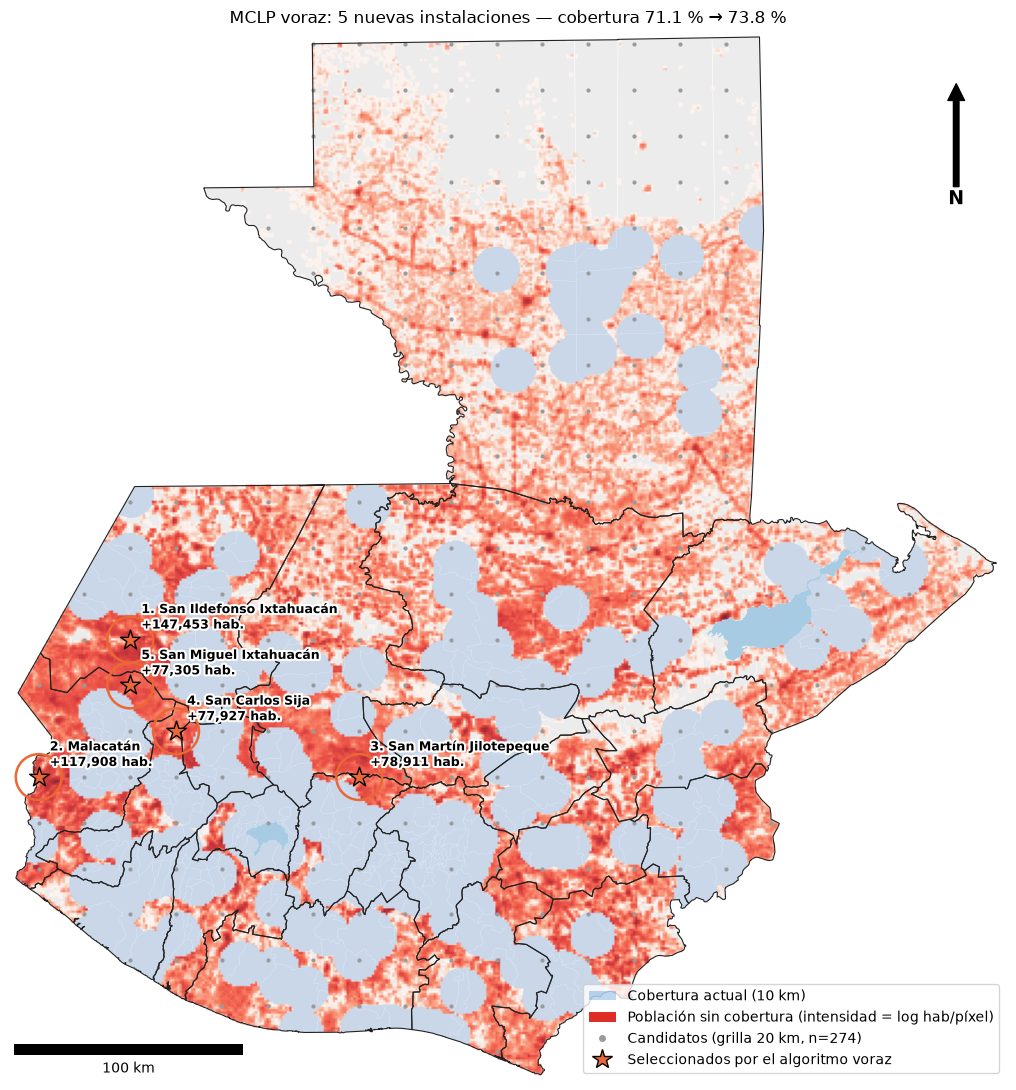

In [28]:
fig, ax = plt.subplots(figsize=(11, 11))
mun.plot(ax=ax, color="#ececec", edgecolor="white", linewidth=0.3)
uncov = pop_utm.copy()
uncov_mask = np.zeros_like(pop_utm, dtype=bool)
uncov_mask[inside] = ~covered
extent = (dst_transform.c, dst_transform.c + W * 1000, dst_transform.f - H * 1000, dst_transform.f)
ax.imshow(np.ma.masked_where(~uncov_mask | (pop_utm <= 0), np.log10(np.clip(pop_utm, 1, None))),
          extent=extent, cmap="Reds", alpha=0.85, zorder=2)
water_p.plot(ax=ax, color="#a6cbe3", zorder=2)
gpd.GeoSeries([cov10.intersection(country_p)], crs=CRS_PROJ).plot(ax=ax, color="#2a78d6", alpha=0.18, zorder=1)
cand.plot(ax=ax, color="#9a9a9a", markersize=4, zorder=3)
gpd.GeoSeries(sel.geometry.buffer(S), crs=CRS_PROJ).boundary.plot(ax=ax, color=CAT[1], linewidth=1.8, zorder=4)
sel.plot(ax=ax, color=CAT[1], marker="*", markersize=220, edgecolor="black", zorder=5)
for _, r in sel.iterrows():
    ax.annotate(f"{r.iteracion}. {r.NAME_2}\n+{r.pob_adicional:,.0f} hab.", xy=(r.geometry.x, r.geometry.y),
                xytext=(8, 8), textcoords="offset points", fontsize=9, fontweight="bold",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")], zorder=6)
gadm1_p.boundary.plot(ax=ax, color="#222222", linewidth=0.8, zorder=3)
ax.legend(handles=[
    Patch(facecolor="#2a78d6", alpha=0.3, label="Cobertura actual (10 km)"),
    Patch(facecolor="#de2d26", label="Población sin cobertura (intensidad = log hab/píxel)"),
    Line2D([], [], marker="o", color="#9a9a9a", ls="", markersize=4, label=f"Candidatos (grilla 20 km, n={len(cand)})"),
    Line2D([], [], marker="*", color=CAT[1], markeredgecolor="black", ls="", markersize=15,
           label="Seleccionados por el algoritmo voraz")], loc="lower right")
add_north_and_scale(ax)
ax.set_title(f"MCLP voraz: 5 nuevas instalaciones — cobertura {base_pct:.1f} % → "
             f"{greedy_tbl.pct_cobertura_acumulada.iloc[-1]:.1f} %")
ax.set_axis_off()
plt.tight_layout()
plt.show()